# Verifications

In [1]:
# bibliotecques
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Chemin d'accès 
ROOT = Path.cwd().parent 
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
print(f"Project root: {ROOT}")

from src.data_loader import *
from src.periodicity import *
from src.hull_white import *
from src.sinusoidal_hw import *
from src.monte_carlo import *
from src.calibration import *
print("Imports OK")

Project root: C:\Users\Manuel\Desktop\sinusoidal_hw
Imports OK


# Importation des données 

Chargement depuis : C:\Users\Manuel\Desktop\sinusoidal_hw\data\fredgraph.csv
Données chargées. 1292 lignes supprimées (NaN/Jours fériés).
Période: 1993-10-01 à 2022-12-30


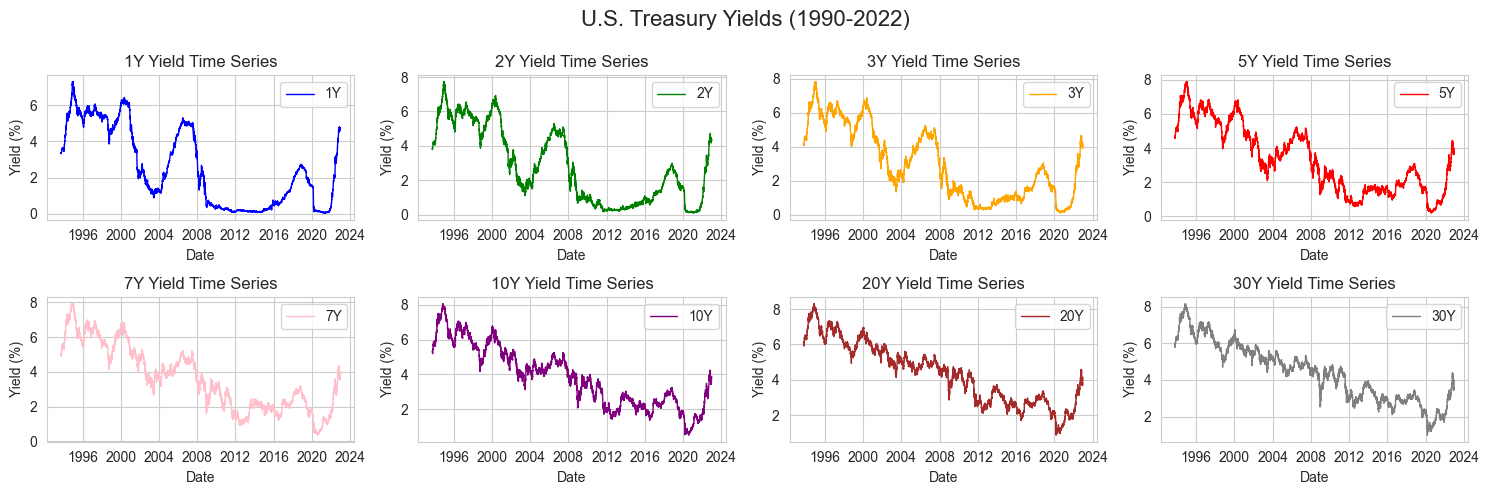

In [30]:
data_path = ROOT / 'data' / 'fredgraph.csv'

# Configuration du style graphique
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 10)

# Chargement et Graphiques
if not data_path.exists():
    print(f"ERREUR : Le fichier n'est pas trouvé à : {data_path}")
else:
    print(f"Chargement depuis : {data_path}")
    loader = YieldDataLoader(str(data_path))
    df_yields = loader.load_data()

    #Figure series temporelles
    fig, axes = plt.subplots(2, 4, figsize=(15, 5))
    fig.suptitle('U.S. Treasury Yields (1990-2022)', fontsize=16)

    tenors_to_plot = ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
    colors = ['blue', 'green', 'orange', 'red', 'pink', 'purple', 'brown', 'gray']

    for ax, tenor, color in zip(axes.flatten(), tenors_to_plot, colors):
        if tenor in df_yields.columns:
            # On remultiplie par 100 juste pour l'affichage graphique (en %)
            ax.plot(df_yields.index, df_yields[tenor] * 100, label=tenor, color=color, linewidth=1)
            ax.set_title(f'{tenor} Yield Time Series')
            ax.set_ylabel('Yield (%)')
            ax.set_xlabel('Date')
            ax.legend()
        else:
            ax.text(0.5, 0.5, f"{tenor} data not found", ha='center')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    # plt.savefig("Data.png", dpi=300, bbox_inches='tight')
    plt.show()

In [6]:
print(df_yields.describe())

                1Y           2Y           3Y           5Y           7Y  \
count  7317.000000  7317.000000  7317.000000  7317.000000  7317.000000   
mean      0.025389     0.027874     0.029792     0.033319     0.036249   
std       0.021739     0.021653     0.020983     0.019541     0.018549   
min       0.000400     0.000900     0.001000     0.001900     0.003600   
25%       0.003500     0.007300     0.010400     0.016400     0.020500   
50%       0.020300     0.023300     0.025100     0.029800     0.033800   
75%       0.048700     0.048000     0.047800     0.049100     0.050700   
max       0.073200     0.077400     0.078400     0.079000     0.079200   

               10Y          20Y          30Y  
count  7317.000000  7317.000000  7317.000000  
mean      0.038526     0.043624     0.044070  
std       0.017412     0.017080     0.015679  
min       0.005200     0.008700     0.009900  
25%       0.023500     0.027900     0.030300  
50%       0.038100     0.044900     0.045300  
75% 